In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [3]:
# Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [4]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se

#### 0. CARGA

In [5]:
df = sc.leer_csv('../data/processed/02_datos_limpios.csv')

CSV CARGADO
Archivo: ../data/processed/02_datos_limpios.csv
Filas:   1000
Columnas: 12


In [6]:
df_e = df.copy()

#### 1. EDA PRELIMINAR - CALIDAD DEL DATASET

##### EXPLORACION INICIAL

In [7]:
se.exploracion(df_e, cols_excluir=None)

PRIMERAS COLUMNAS


,577,353,389
horas_estudio_semanal,9.01,16.26,13.56
nota_anterior,80.63,82.29,63.74
tasa_asistencia,100.0,75.93,81.46
horas_sueno,7.42,7.01,7.01
edad,23,24,18
nivel_dificultad,medio,dificil,facil
tiene_tutor,si,si,no
horario_estudio_preferido,tarde,manana,manana
estilo_aprendizaje,lectura_escritura,lectura_escritura,auditivo
nota_final,78.8,78.1,66.8


::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
INFORMACIÓN BÁSICA
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                1000 non-null   float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   str    
 6   tiene_tutor                1000 non-null   str    
 7   horario_estudio_preferido  1000 non-null   str    
 8   estilo_aprendizaje         1000 non-null   str    
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
 11  tiene_tutor_ml             1000 non-null   int64  
d

None

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
ESTADISTICOS


...

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
TAMAÑO DATAFRAME
(1000, 12)
DUPLICADOS
0
::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
NULOS


Series([], dtype: int64)

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
PORCENTAJE DE NULOS


Series([], dtype: float64)

::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
REPRESENTACION GRAFICA DE VALORES NULOS
No hay columnas con nulos, no se genera el gráfico.


##### VARIABLES NUMERICAS

Las columnas `aprobado` y `tiene_tutor_ml` son binarias, por lo que las excluiremos en eda_numéricas y se estudiaran de forma indepenciente. 

VARIABLES NUMERICAS: ['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'nota_final']
                        count   mean    std   min    25%    50%    75%    max
horas_estudio_semanal  1000.0  10.07   4.85   1.0   6.63  10.00  13.37   25.0
nota_anterior          1000.0  69.89  14.69  30.0  59.88  70.00  80.12  100.0
tasa_asistencia        1000.0  73.99  18.20  20.0  61.51  75.00  88.49  100.0
horas_sueno            1000.0   7.01   1.33   4.0   6.19   7.01   7.82   10.0
edad                   1000.0  23.53   3.48  18.0  21.00  24.00  27.00   29.0
nota_final             1000.0  71.44   9.56  30.0  64.78  71.40  77.90  100.0


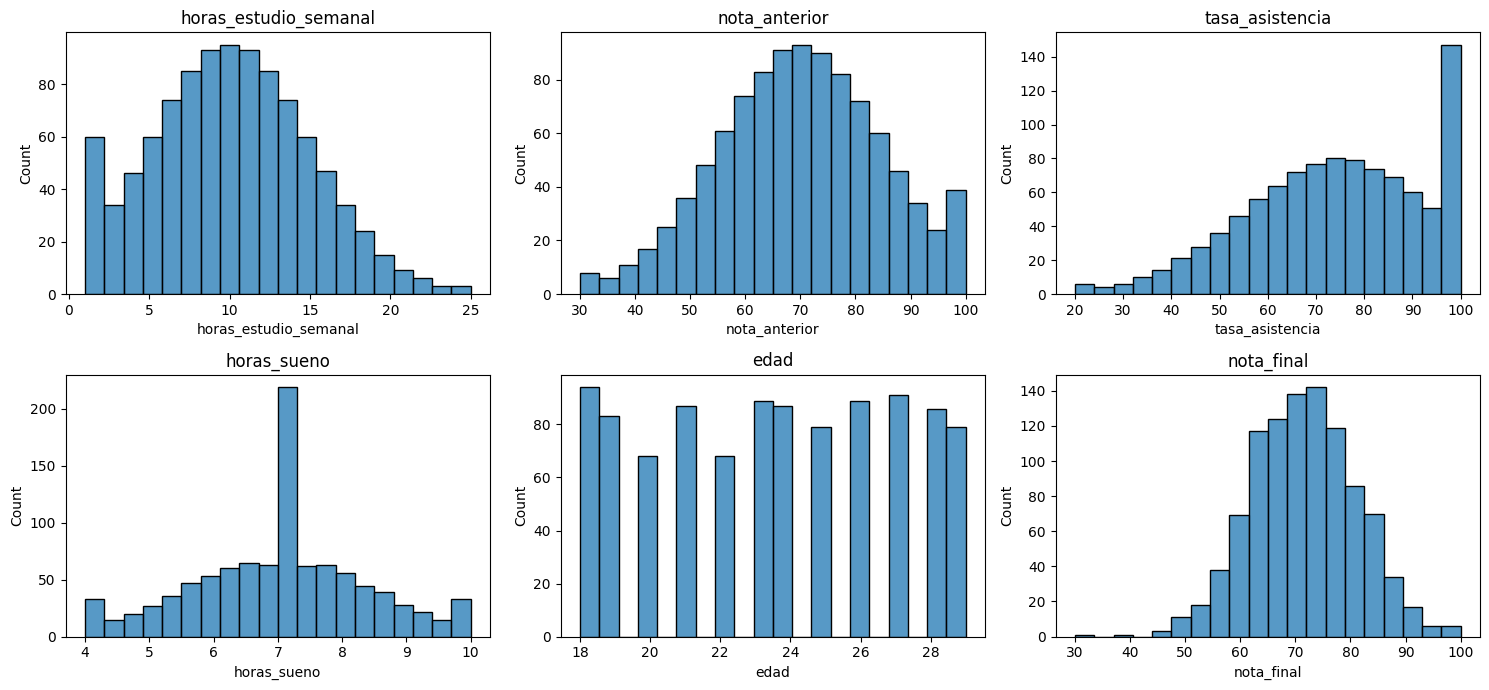

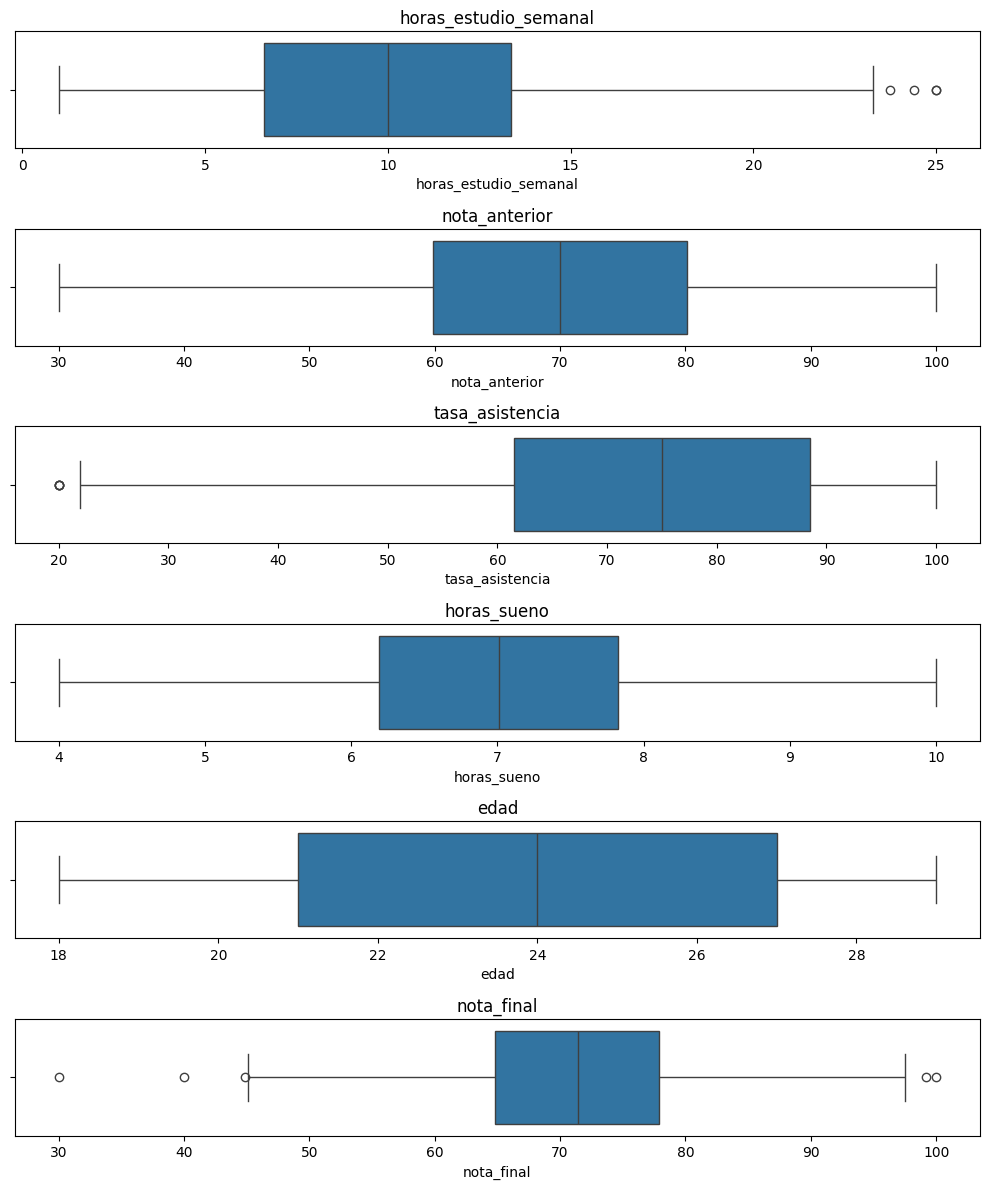

In [8]:
se.eda_numericas(df_e, cols_excluir=['aprobado', 'tiene_tutor_ml'])

Buenos gráficos, con dos cosas que llaman la atención de verdad — una interesante, otra que hay que revisar.

🌟 tasa_asistencia — una forma muy poco habitual

Mira el histograma: en vez de una campana normal, tiene una barra enorme pegada justo en 100 (147 estudiantes exactos con asistencia perfecta), mientras el resto de la distribución sube de forma bastante lineal desde 20 hasta ahí. Esto no es ruido — es un patrón real y merece investigarse: ¿esos 147 estudiantes con 100% de asistencia tienen algo en común (mejores notas, más horas de estudio)? Es candidato fuerte para el bivariante.

🟡 horas_sueno — un pico raro justo en 7

Fíjate en la barra de "7" del histograma: destaca muchísimo por encima de sus vecinas (más del triple que las de al lado), en una variable que por lo demás tiene forma suave. Esto no encaja con una distribución continua natural — parece indicar que muchos de los nulos que imputaste con la media/mediana cayeron ahí (recuerda: la media de horas_sueno era 7,01). Si imputaste con imputar_media() o imputar_mediana(), es exactamente ese efecto: 150 valores que antes eran NaN ahora se apilan todos en el mismo número, creando un pico artificial que no representa la variabilidad real de "cuánto duerme cada estudiante".

Esto no es un error de tu código — es un efecto secundario esperado de imputar con un valor único, pero conviene documentarlo, porque si alguien mira el histograma sin saberlo, podría pensar que hay algo raro en el dato original cuando en realidad es un artefacto de tu propia limpieza.

*Los boxplots, en general, están limpios*

horas_estudio_semanal (3 outliers altos), tasa_asistencia (1 outlier bajo), nota_final (5 outliers, dos en cada extremo) — coinciden con lo que ya revisamos caso por caso en el paso 7 y decidimos conservar. nota_anterior, horas_sueno, edad sin ningún outlier marcado.

HORAS DE SUEÑO

In [9]:
df_e['horas_sueno'].value_counts().sort_index().loc[6.99:7.03]

horas_sueno
6.99      2
7.00      2
7.01    153
7.02      2
7.03      2
Name: count, dtype: int64

In [10]:
df_e[df_e['horas_sueno'] == 7.01].shape[0]

153

`horas_sueno` — pico artificial en 7.01 por imputación

153 de 1000 estudiantes (15,3%) tienen exactamente horas_sueno=7.01,
un valor que destaca de forma anómala en el histograma frente a sus
vecinos (1-3 casos cada uno). Corresponde a los 150 nulos originales
de esta columna, imputados con la media en Fase 2. No es un patrón
real del comportamiento de sueño de los estudiantes, sino un
artefacto de la imputación — documentado para no interpretarlo
erróneamente como un hallazgo de negocio.

TASAS DE ASISTENCIA

In [11]:
(df_e['tasa_asistencia'] == 100.0).sum()

np.int64(106)

In [12]:
df_e['asistencia_perfecta'] = df_e['tasa_asistencia'] == 100.0
df_e.groupby('asistencia_perfecta')[['nota_final', 'nota_anterior', 'horas_estudio_semanal', 'aprobado']].mean().round(2).T

asistencia_perfecta,False,True
nota_final,70.94,75.67
nota_anterior,68.98,77.54
horas_estudio_semanal,9.93,11.29
aprobado,0.89,0.97


`tasa_asistencia=100%` — grupo con mejor rendimiento general

106 estudiantes (10,6%) tienen asistencia perfecta (100%). Este
grupo muestra mejores resultados en todas las variables de
rendimiento: 
- nota_final +4,7 puntos.
- nota_anterior +8,6 puntos.
- horas_estudio_semanal +1,4 horas. 
- tasa de aprobado 97% vs 89%.

##### VARIABLES CATEGORICAS

VARIABLES CATEGORICAS: ['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']
                          count unique     top freq
nivel_dificultad           1000      3   medio  504
tiene_tutor                1000      2      no  597
horario_estudio_preferido  1000      3   noche  444
estilo_aprendizaje         1000      4  visual  413

----------- nivel_dificultad -----------
Valores únicos: <ArrowStringArray>
['facil', 'dificil', 'medio']
Length: 3, dtype: str
Frecuencia:
nivel_dificultad
medio      504
facil      313
dificil    183
Name: count, dtype: int64

----------- tiene_tutor -----------
Valores únicos: <ArrowStringArray>
['si', 'no']
Length: 2, dtype: str
Frecuencia:
tiene_tutor
no    597
si    403
Name: count, dtype: int64

----------- horario_estudio_preferido -----------
Valores únicos: <ArrowStringArray>
['tarde', 'manana', 'noche']
Length: 3, dtype: str
Frecuencia:
horario_estudio_preferido
noche     444
tarde     337
manana    219
Name: c

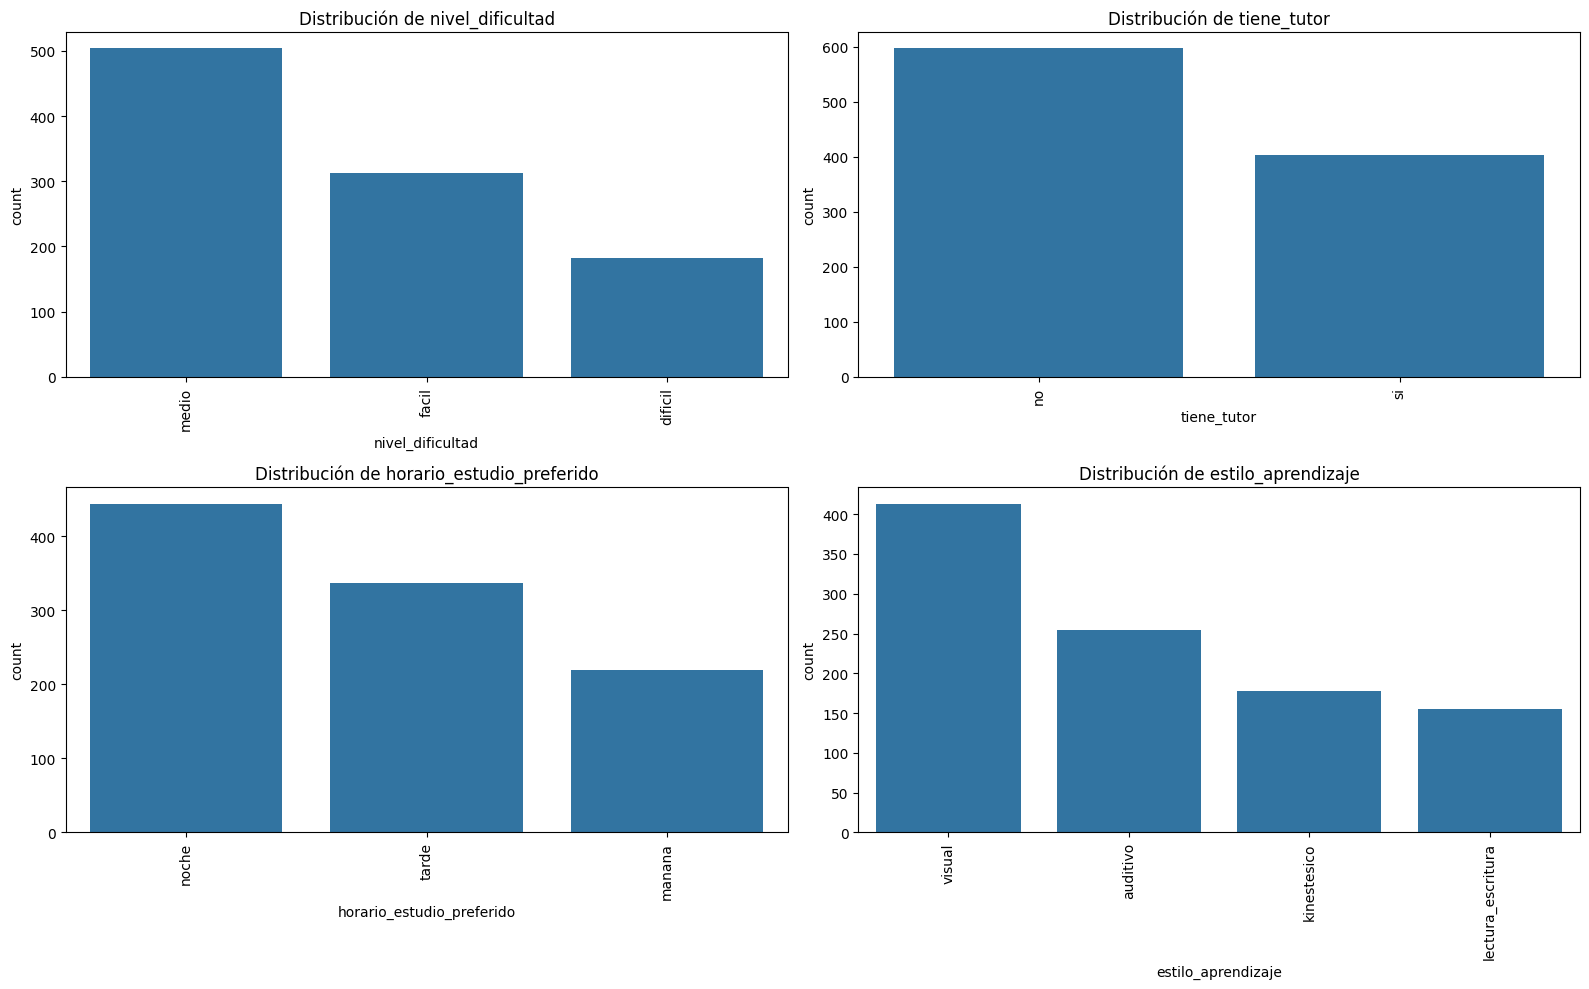

In [13]:
se.eda_categoricas(df_e)

In [14]:
col_cat = df_e.select_dtypes(include='string').columns
col_cat

Index(['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje'], dtype='str')

In [15]:
for col in col_cat:
    print("-"*50)
    print(col.upper())
    print("-"*50)
    print((df[col].value_counts(normalize=True).round(2))*100)
  

--------------------------------------------------
NIVEL_DIFICULTAD
--------------------------------------------------
nivel_dificultad
medio      50.0
facil      31.0
dificil    18.0
Name: proportion, dtype: float64
--------------------------------------------------
TIENE_TUTOR
--------------------------------------------------
tiene_tutor
no    60.0
si    40.0
Name: proportion, dtype: float64
--------------------------------------------------
HORARIO_ESTUDIO_PREFERIDO
--------------------------------------------------
horario_estudio_preferido
noche     44.0
tarde     34.0
manana    22.0
Name: proportion, dtype: float64
--------------------------------------------------
ESTILO_APRENDIZAJE
--------------------------------------------------
estilo_aprendizaje
visual               41.0
auditivo             25.0
kinestesico          18.0
lectura_escritura    16.0
Name: proportion, dtype: float64


Lectura general de las 4 categóricas
- nivel_dificultad: medio (50,4%) > facil (31,3%) > dificil (18,3%) — reparto razonable, sin categorías raras.
- tiene_tutor: no (59,7%) > si (40,3%) — mayoría sin tutor, coherente con lo que ya sabías.
horario_estudio_preferido: noche domina claramente (44,4%) tras la imputación.
- estilo_aprendizaje: visual domina (41,3%), - lectura_escritura la menos común (15,5%) — ninguna con muestra tan pequeña como el analfabeto del otro proyecto (18 casos), así que aquí no hay que preocuparse por fiabilidad de categorías minoritarias.

#### MATRIZ DE CORRELACION

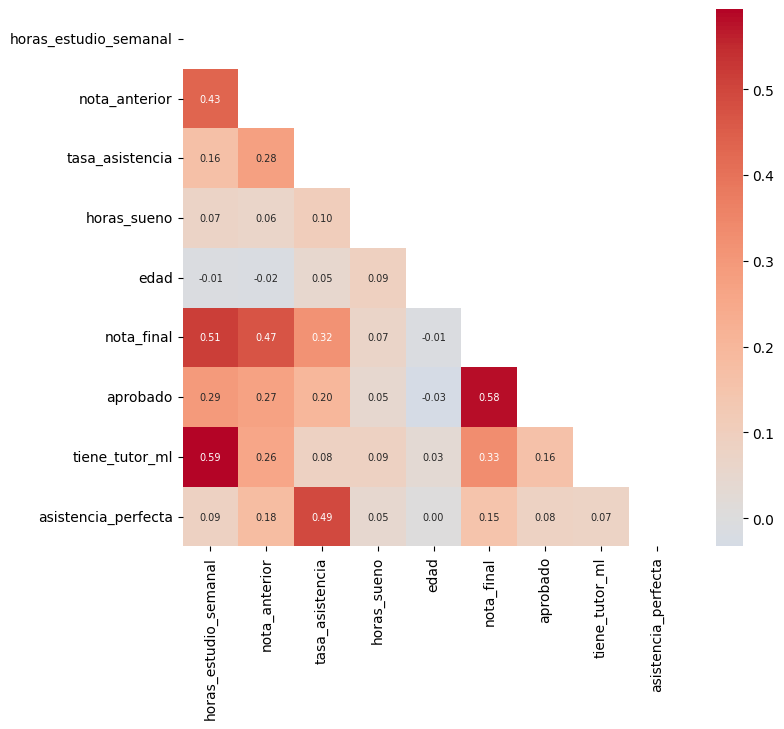

Top 10 pares con mayor correlación (valor absoluto):
horas_estudio_semanal  tiene_tutor_ml           0.593473
aprobado               nota_final               0.578919
nota_final             horas_estudio_semanal    0.513547
tasa_asistencia        asistencia_perfecta      0.492418
nota_final             nota_anterior            0.469788
nota_anterior          horas_estudio_semanal    0.431679
tiene_tutor_ml         nota_final               0.330901
tasa_asistencia        nota_final               0.316770
aprobado               horas_estudio_semanal    0.292955
nota_anterior          tasa_asistencia          0.276349
dtype: float64


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nota_final,aprobado,tiene_tutor_ml,asistencia_perfecta
horas_estudio_semanal,1.000000,0.431679,0.164849,0.072579,-0.009338,0.513547,0.292955,0.593473,0.086112
nota_anterior,0.431679,1.000000,0.276349,0.064591,-0.015299,0.469788,0.270670,0.256642,0.179625
tasa_asistencia,0.164849,0.276349,1.000000,0.102921,0.051926,0.316770,0.204257,0.084585,0.492418
horas_sueno,0.072579,0.064591,0.102921,1.000000,0.092203,0.069432,0.046223,0.089107,0.046684
edad,-0.009338,-0.015299,0.051926,0.092203,1.000000,-0.012204,-0.033026,0.032034,0.001503
nota_final,0.513547,0.469788,0.316770,0.069432,-0.012204,1.000000,0.578919,0.330901,0.152276
aprobado,0.292955,0.270670,0.204257,0.046223,-0.033026,0.578919,1.000000,0.162385,0.083850
tiene_tutor_ml,0.593473,0.256642,0.084585,0.089107,0.032034,0.330901,0.162385,1.000000,0.074718
asistencia_perfecta,0.086112,0.179625,0.492418,0.046684,0.001503,0.152276,0.083850,0.074718,1.000000


In [16]:
se.matriz_correlacion(df_e)

horas_estudio_semanal <-> tiene_tutor_ml    0.593

In [17]:
df_e.groupby('tiene_tutor')['horas_estudio_semanal'].mean().round(2)

tiene_tutor
no     7.71
si    13.58
Name: horas_estudio_semanal, dtype: float64

`tiene_tutor` <-> `horas_estudio_semanal` — la correlación más fuerte del dataset (0,593)

Los estudiantes con tutor dedican de media 13,58 horas semanales de
estudio, frente a 7,71 horas de quienes no lo tienen — casi el doble.

No se puede establecer causalidad con los datos disponibles: podría
ser que el tutor fomente más horas de estudio, o que los estudiantes
ya predispuestos a estudiar mucho sean quienes buscan tutor. Ambas
variables correlacionan con nota_final (0,331 y 0,514
respectivamente) — su fuerte relación mutua introduce riesgo de
multicolinealidad de cara al modelado, similar al caso de las
variables macroeconómicas del proyecto anterior.

In [18]:
se.corr_objetivo(df_e,'nota_final')

Correlación con nota_final:
aprobado                 0.579
horas_estudio_semanal    0.514
nota_anterior            0.470
tiene_tutor_ml           0.331
tasa_asistencia          0.317
asistencia_perfecta      0.152
horas_sueno              0.069
edad                    -0.012
Name: nota_final, dtype: float64


In [19]:
se.corr_objetivo(df_e,'aprobado')

Correlación con aprobado:
nota_final               0.579
horas_estudio_semanal    0.293
nota_anterior            0.271
tasa_asistencia          0.204
tiene_tutor_ml           0.162
asistencia_perfecta      0.084
horas_sueno              0.046
edad                    -0.033
Name: aprobado, dtype: float64


Ranking de variables — consistente entre regresión y clasificación

Las 3 variables con mayor relación con el rendimiento académico son
las mismas y en el mismo orden para ambos objetivos:
1. horas_estudio_semanal
2. nota_anterior
3. tasa_asistencia

tiene_tutor_ml es más relevante para explicar la nota exacta (0,331)
que para el corte binario aprobado/suspenso (0,162) — probablemente
porque su efecto se solapa con horas_estudio_semanal (correlación
entre ambas de 0,593).

horas_sueno y edad no muestran relación relevante con ningún
objetivo — ni edad ni cantidad de sueño parecen influir en el
rendimiento en este dataset.

#### BIVARIANTES CATEGORICAS

**`nivel_dificultad`**

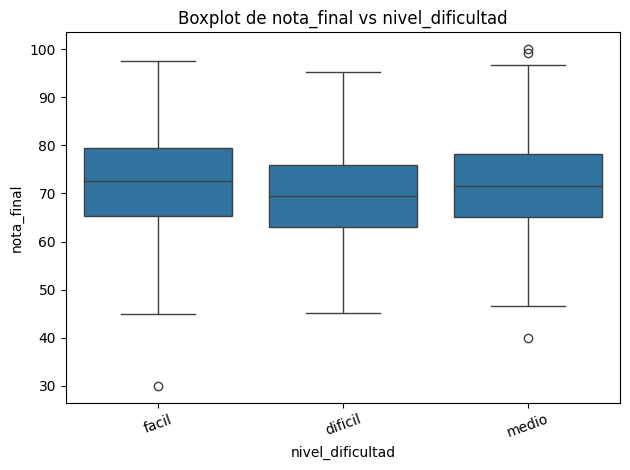

Resumen de nota_final por nivel_dificultad:
                  count   mean   std   min   25%    50%    75%    max
nivel_dificultad                                                     
dificil           183.0  69.48  9.42  45.1  63.0  69.40  75.95   95.2
facil             313.0  72.50  9.75  30.0  65.4  72.60  79.50   97.5
medio             504.0  71.49  9.40  40.0  65.0  71.45  78.12  100.0


In [20]:
se.boxplot_bivar(df_e, 'nivel_dificultad', 'nota_final')


In [21]:
(pd.crosstab(df_e['nivel_dificultad'], df_e['aprobado'], normalize='index').round(3))*100

aprobado,0,1
nivel_dificultad,,
dificil,15.3,84.7
facil,8.3,91.7
medio,9.5,90.5


In [22]:
from framework import sp_abtest as sb

In [23]:
sb.chi_cuadrado_independencia(df_e, 'nivel_dificultad', 'aprobado')

chi2=6.674, p=0.0355, dof=2
SI hay relación entre nivel_dificultad y aprobado


In [24]:
sb.decidir_test(df_e, 'nivel_dificultad', ['nota_final'])

--- NOTA_FINAL | normalidad=True | homocedastico=True | n_grupos=3 ---
F=5.8578, p=0.0030
Para la métrica NOTA_FINAL, al menos un grupo de nivel_dificultad tiene una media distinta (ANOVA significativo)
Post-hoc Tukey (qué pares difieren):


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower  upper  reject
----------------------------------------------------
dificil  facil   3.0268 0.0019  0.9483 5.1053   True
dificil  medio   2.0178 0.0377  0.0901 3.9455   True
  facil  medio   -1.009 0.3042 -2.6164 0.5984  False
----------------------------------------------------


- dificil vs facil:  diferencia de 3,03 puntos, p=0,0019 -> SIGNIFICATIVO
- dificil vs medio:  diferencia de 2,02 puntos, p=0,0377 -> SIGNIFICATIVO
- facil vs medio:    diferencia de 1,01 puntos, p=0,3042 -> NO significativo

`nivel_dificultad` — efecto real, pero no lineal (confirmado con Tukey)

Chi-cuadrado confirma relación con aprobado (p=0,036) y ANOVA con
nota_final (p=0,003). El post-hoc de Tukey revela que el efecto NO
es un gradiente de 3 niveles: facil y medio no difieren
significativamente entre sí (p=0,30), pero dificil sí se separa
claramente de ambos (-3,03 puntos vs facil, -2,02 vs medio, ambos
significativos).

Implicación para preprocesamiento: se recomienda codificación One-Hot
en lugar de ordinal, ya que forzar una progresión lineal (1,2,3)
distorsionaría la relación real, que es más bien "dificil" vs
"no dificil" que una escala progresiva.

**`horario_estudio_preferido`**

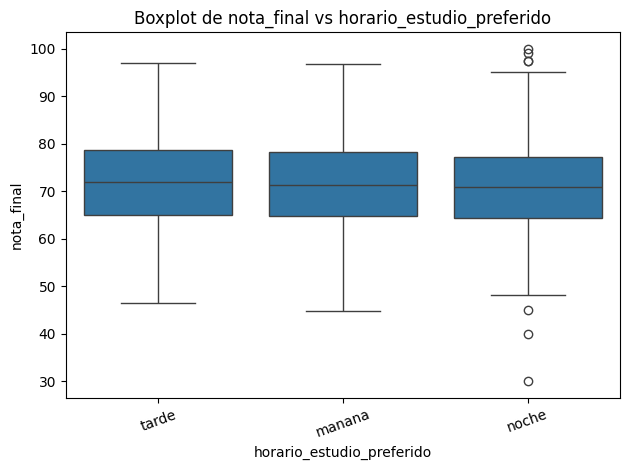

Resumen de nota_final por horario_estudio_preferido:
                           count   mean   std   min    25%    50%   75%    max
horario_estudio_preferido                                                     
manana                     219.0  71.60  9.53  44.9  64.80  71.40  78.3   96.8
noche                      444.0  71.16  9.88  30.0  64.47  70.95  77.2  100.0
tarde                      337.0  71.71  9.16  46.5  65.00  72.00  78.8   97.0


In [25]:
se.boxplot_bivar(df_e, 'horario_estudio_preferido', 'nota_final')


In [26]:
pd.crosstab(df_e['horario_estudio_preferido'], df_e['aprobado'], normalize='index').round(3)

aprobado,0,1
horario_estudio_preferido,,
manana,0.087,0.913
noche,0.115,0.885
tarde,0.095,0.905


In [27]:
sb.decidir_test(df_e, 'horario_estudio_preferido', ['nota_final'])

--- NOTA_FINAL | normalidad=True | homocedastico=True | n_grupos=3 ---
F=0.3541, p=0.7019
Para la métrica NOTA_FINAL, las medias SI son iguales entre los grupos de horario_estudio_preferido (ANOVA no significativo)


In [28]:
sb.chi_cuadrado_independencia(df_e, 'horario_estudio_preferido', 'aprobado')

chi2=1.540, p=0.4629, dof=2
NO hay evidencia de relación entre horario_estudio_preferido y aprobado


`horario_estudio_preferido` — sin relación relevante

No se detecta relación significativa con nota_final (ANOVA, p=0,702)
ni con aprobado (chi-cuadrado, p=0,463). Las medias de nota_final son
prácticamente idénticas entre mañana (71,60), tarde (71,71) y noche
(71,16). El momento del día elegido para estudiar no parece influir
en el rendimiento — lo que importa es cuántas horas se estudian
(horas_estudio_semanal), no cuándo.

Nota: el grupo "noche" presenta mayor dispersión (std=9,88) y
concentra tanto los mejores como los peores resultados extremos del
dataset, aunque sin desplazar la media.

**`estilo_aprendizaje`**

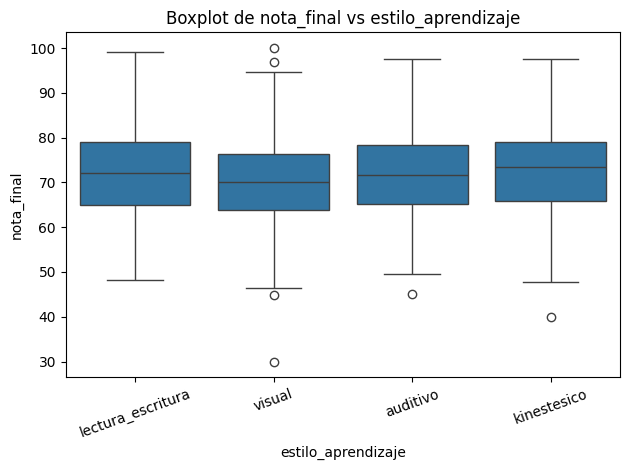

Resumen de nota_final por estilo_aprendizaje:
                    count   mean   std   min    25%    50%    75%    max
estilo_aprendizaje                                                      
auditivo            254.0  71.82  9.49  45.1  65.18  71.70  78.25   97.5
kinestesico         178.0  72.53  9.56  40.0  65.75  73.35  78.95   97.5
lectura_escritura   155.0  72.59  9.57  48.2  65.05  72.00  79.10   99.2
visual              413.0  70.31  9.51  30.0  63.90  70.10  76.40  100.0


In [29]:
se.boxplot_bivar(df_e, 'estilo_aprendizaje', 'nota_final')

In [30]:
(pd.crosstab(df_e['estilo_aprendizaje'], df_e['aprobado'], normalize='index').round(3))*100

aprobado,0,1
estilo_aprendizaje,,
auditivo,8.7,91.3
kinestesico,10.1,89.9
lectura_escritura,5.8,94.2
visual,12.8,87.2


In [31]:
sb.decidir_test(df_e, 'estilo_aprendizaje', ['nota_final'])

--- NOTA_FINAL | normalidad=True | homocedastico=True | n_grupos=4 ---
F=3.6216, p=0.0128
Para la métrica NOTA_FINAL, al menos un grupo de estilo_aprendizaje tiene una media distinta (ANOVA significativo)
Post-hoc Tukey (qué pares difieren):
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
         auditivo       kinestesico   0.7162 0.8683 -1.6797  3.1121  False
         auditivo lectura_escritura   0.7779 0.8538 -1.7203  3.2761  False
         auditivo            visual  -1.5099 0.1931 -3.4644  0.4445  False
      kinestesico lectura_escritura   0.0617 0.9999 -2.6311  2.7545  False
      kinestesico            visual  -2.2261 0.0458 -4.4238 -0.0285   True
lectura_escritura            visual  -2.2878 0.0532 -4.5966   0.021  False
--------------------------------------------------------------------------


In [32]:
sb.chi_cuadrado_independencia(df_e, 'estilo_aprendizaje', 'aprobado')

chi2=7.050, p=0.0703, dof=3
NO hay evidencia de relación entre estilo_aprendizaje y aprobado


`estilo_aprendizaje` — señal débil, no concluyente

ANOVA significativo en conjunto (p=0,013), pero el post-hoc de Tukey
revela que solo el par kinestesico-visual difiere de forma
significativa (-2,23 puntos, p=0,046); el resto de comparaciones no
alcanza significancia. Chi-cuadrado contra aprobado no llega al
umbral (p=0,070, por encima de 0,05).

El estilo "visual" muestra consistentemente el peor resultado
(87,2% de aprobados, el más bajo de los 4; menor nota_final media),
pero la evidencia es débil y no se recomienda tratarlo como un
hallazgo firme sin validación adicional (ej. con una muestra mayor).